### Import Libraries and Datasets

In [1]:

import os, numpy as np, pandas as pd, torch, torch.nn as nn
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, f1_score, recall_score,
    roc_auc_score, precision_score, confusion_matrix, roc_curve
)
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/FIU/class_elements/CIS_5370_Principles_of_CyberSecurity/cis_5370_project_files/"

path_normal = path + "WADI_14days_new.csv"
path_attack = path + "WADI_attackdataLABLE.csv"

normal_df = pd.read_csv(path_normal, index_col=0).reset_index(drop=True) # path_* needs to change if running locally.

attack_df = pd.read_csv(path_attack, index_col=0)
attack_df.columns = attack_df.iloc[0]
attack_df = attack_df[1:].reset_index(drop=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### EDA and Preprocessing

In [3]:
# Read data
pd.set_option('display.max_columns', None)
print(normal_df.head(5))
pd.reset_option('display.max_columns') #reset after reading

        Date     Time  1_AIT_001_PV  1_AIT_002_PV  1_AIT_003_PV  1_AIT_004_PV  \
0  9/25/2017  00:00.0       171.155      0.619473       11.5759       504.645   
1  9/25/2017  00:01.0       171.155      0.619473       11.5759       504.645   
2  9/25/2017  00:02.0       171.155      0.619473       11.5759       504.645   
3  9/25/2017  00:03.0       171.155      0.607477       11.5725       504.673   
4  9/25/2017  00:04.0       171.155      0.607477       11.5725       504.673   

   1_AIT_005_PV  1_FIT_001_PV  1_LS_001_AL  1_LS_002_AL  1_LT_001_PV  \
0      0.318319      0.001157            0            0      47.8911   
1      0.318319      0.001157            0            0      47.8911   
2      0.318319      0.001157            0            0      47.8911   
3      0.318438      0.001207            0            0      47.7503   
4      0.318438      0.001207            0            0      47.7503   

   1_MV_001_STATUS  1_MV_002_STATUS  1_MV_003_STATUS  1_MV_004_STATUS  \
0      

In [4]:
# Check near-null columns (>50% missing)
null_pct = normal_df.isna().mean() * 100
print("\n--- Near-null columns (>50%) ---")
print(null_pct[null_pct > 50].sort_values(ascending=False))

# Compute kurtosis
kurt = normal_df.kurtosis(numeric_only=True)

# Rank by kurtosis (high → low)
print("\n--- Top kurtosis features ---")
kurt = kurt.sort_values(ascending=False)

# Select top 1% extreme features
threshold = kurt.quantile(0.99)
selected = kurt[kurt > threshold]

print(selected)


--- Near-null columns (>50%) ---
2_LS_001_AL       100.0
2_LS_002_AL       100.0
2_P_001_STATUS    100.0
2_P_002_STATUS    100.0
dtype: float64

--- Top kurtosis features ---
2B_AIT_002_PV    13605.757192
2A_AIT_002_PV     8607.429054
dtype: float64


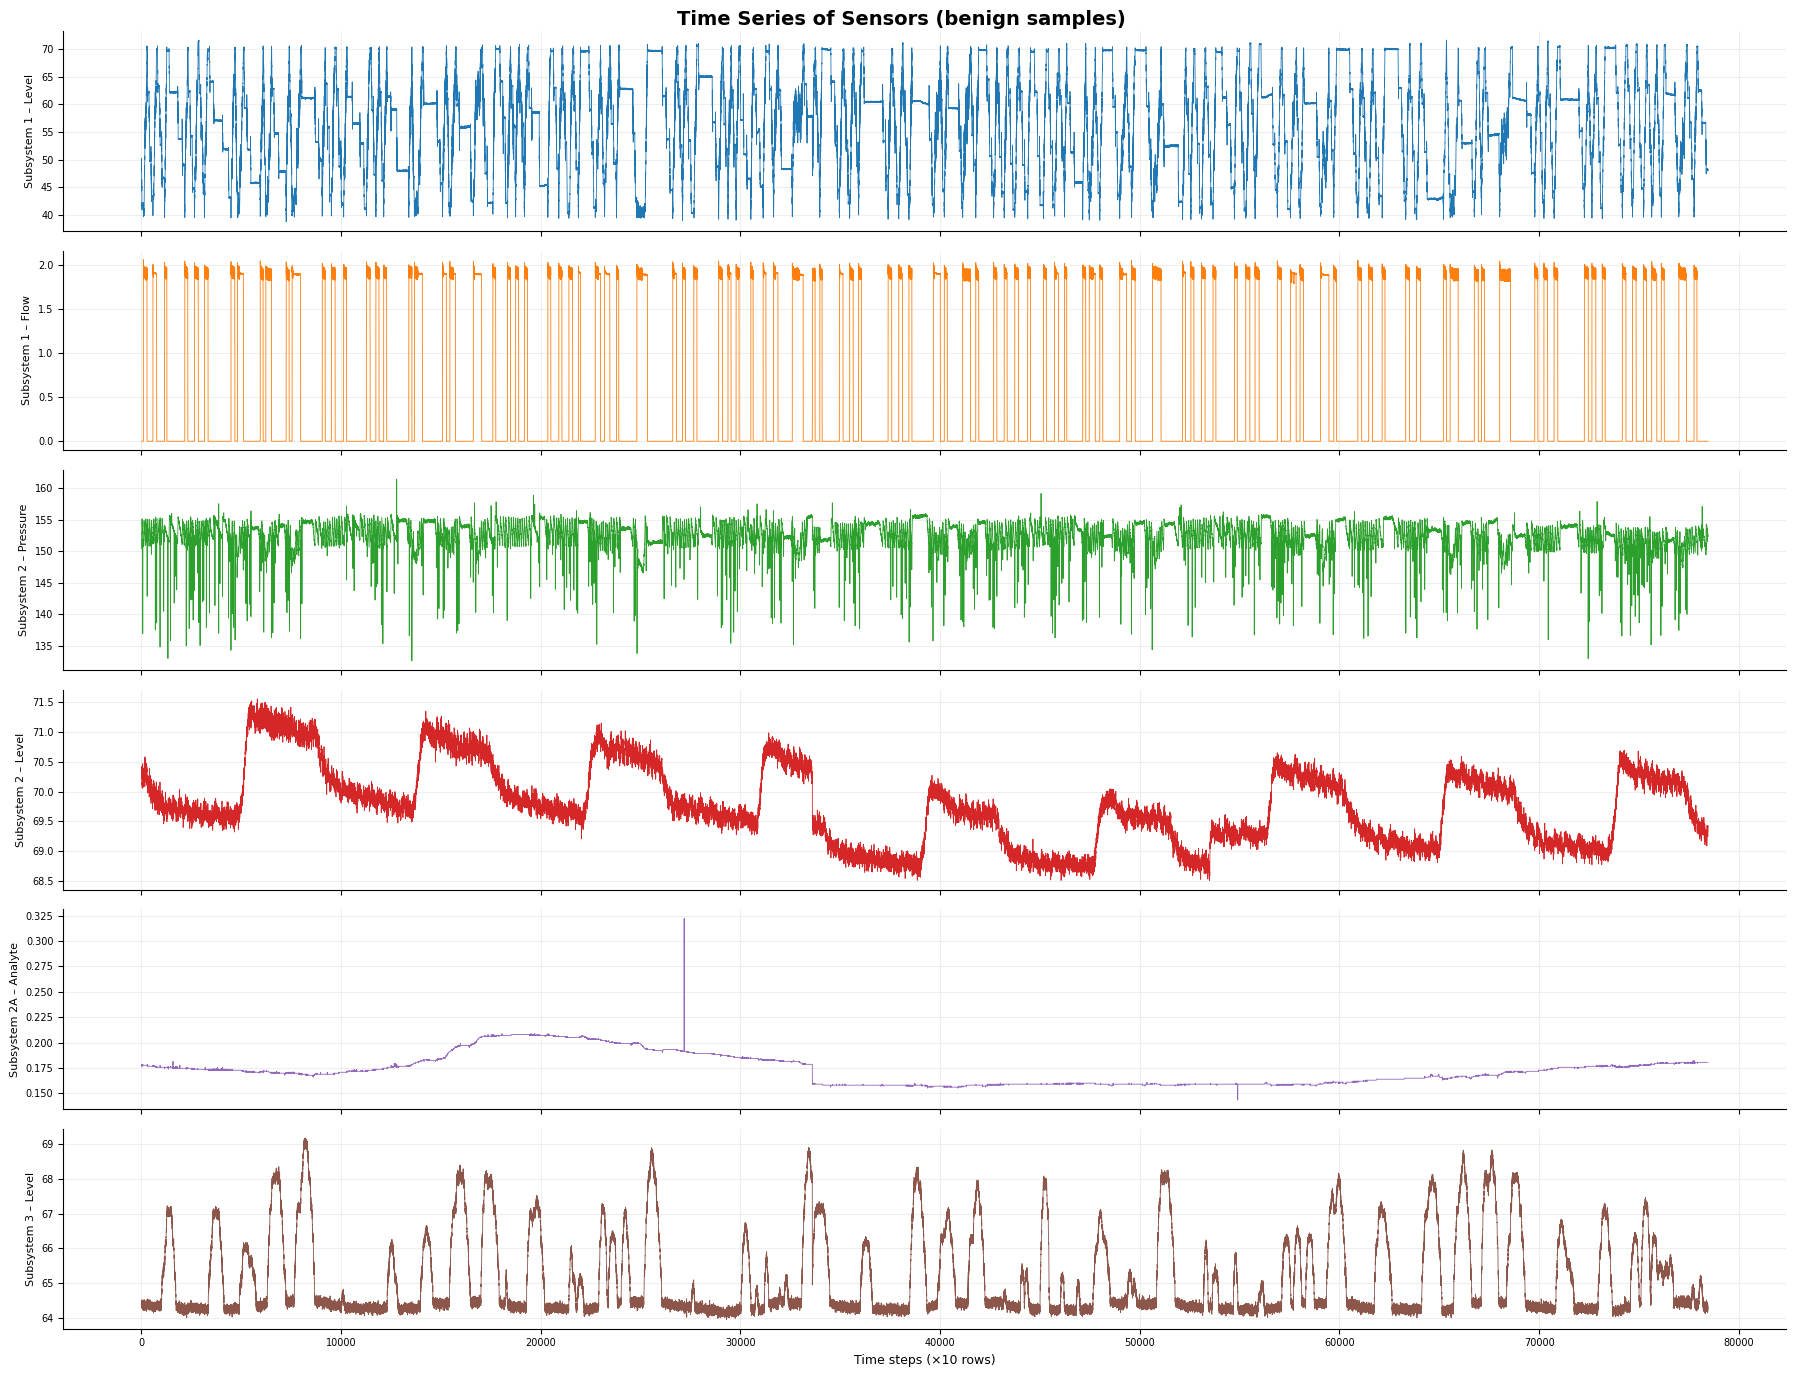

In [5]:
# Time Series Visualization - Benign Data
key_sensors = {
    'Subsystem 1 – Level':    '1_LT_001_PV',
    'Subsystem 1 – Flow':     '1_FIT_001_PV',
    'Subsystem 2 – Pressure': '2_PIT_001_PV',
    'Subsystem 2 – Level':    '2_LT_001_PV',
    'Subsystem 2A – Analyte': '2A_AIT_001_PV',
    'Subsystem 3 – Level':    '3_LT_001_PV',
}

df_ts = normal_df.iloc[::10].reset_index(drop=True)  # downsample for speed

fig, axes = plt.subplots(len(key_sensors), 1, figsize=(18, 14), sharex=True)
fig.suptitle('Time Series of Sensors (benign samples)', fontsize=14, fontweight='bold')

for i, (label, col) in enumerate(key_sensors.items()):
    axes[i].plot(df_ts[col].values, color=plt.cm.tab10.colors[i], linewidth=0.6)
    axes[i].set_ylabel(label, fontsize=8)
    axes[i].tick_params(labelsize=7)
    axes[i].grid(True, alpha=0.2)
    axes[i].spines[['top', 'right']].set_visible(False)

axes[-1].set_xlabel('Time steps (×10 rows)', fontsize=9)
plt.tight_layout()
plt.show()

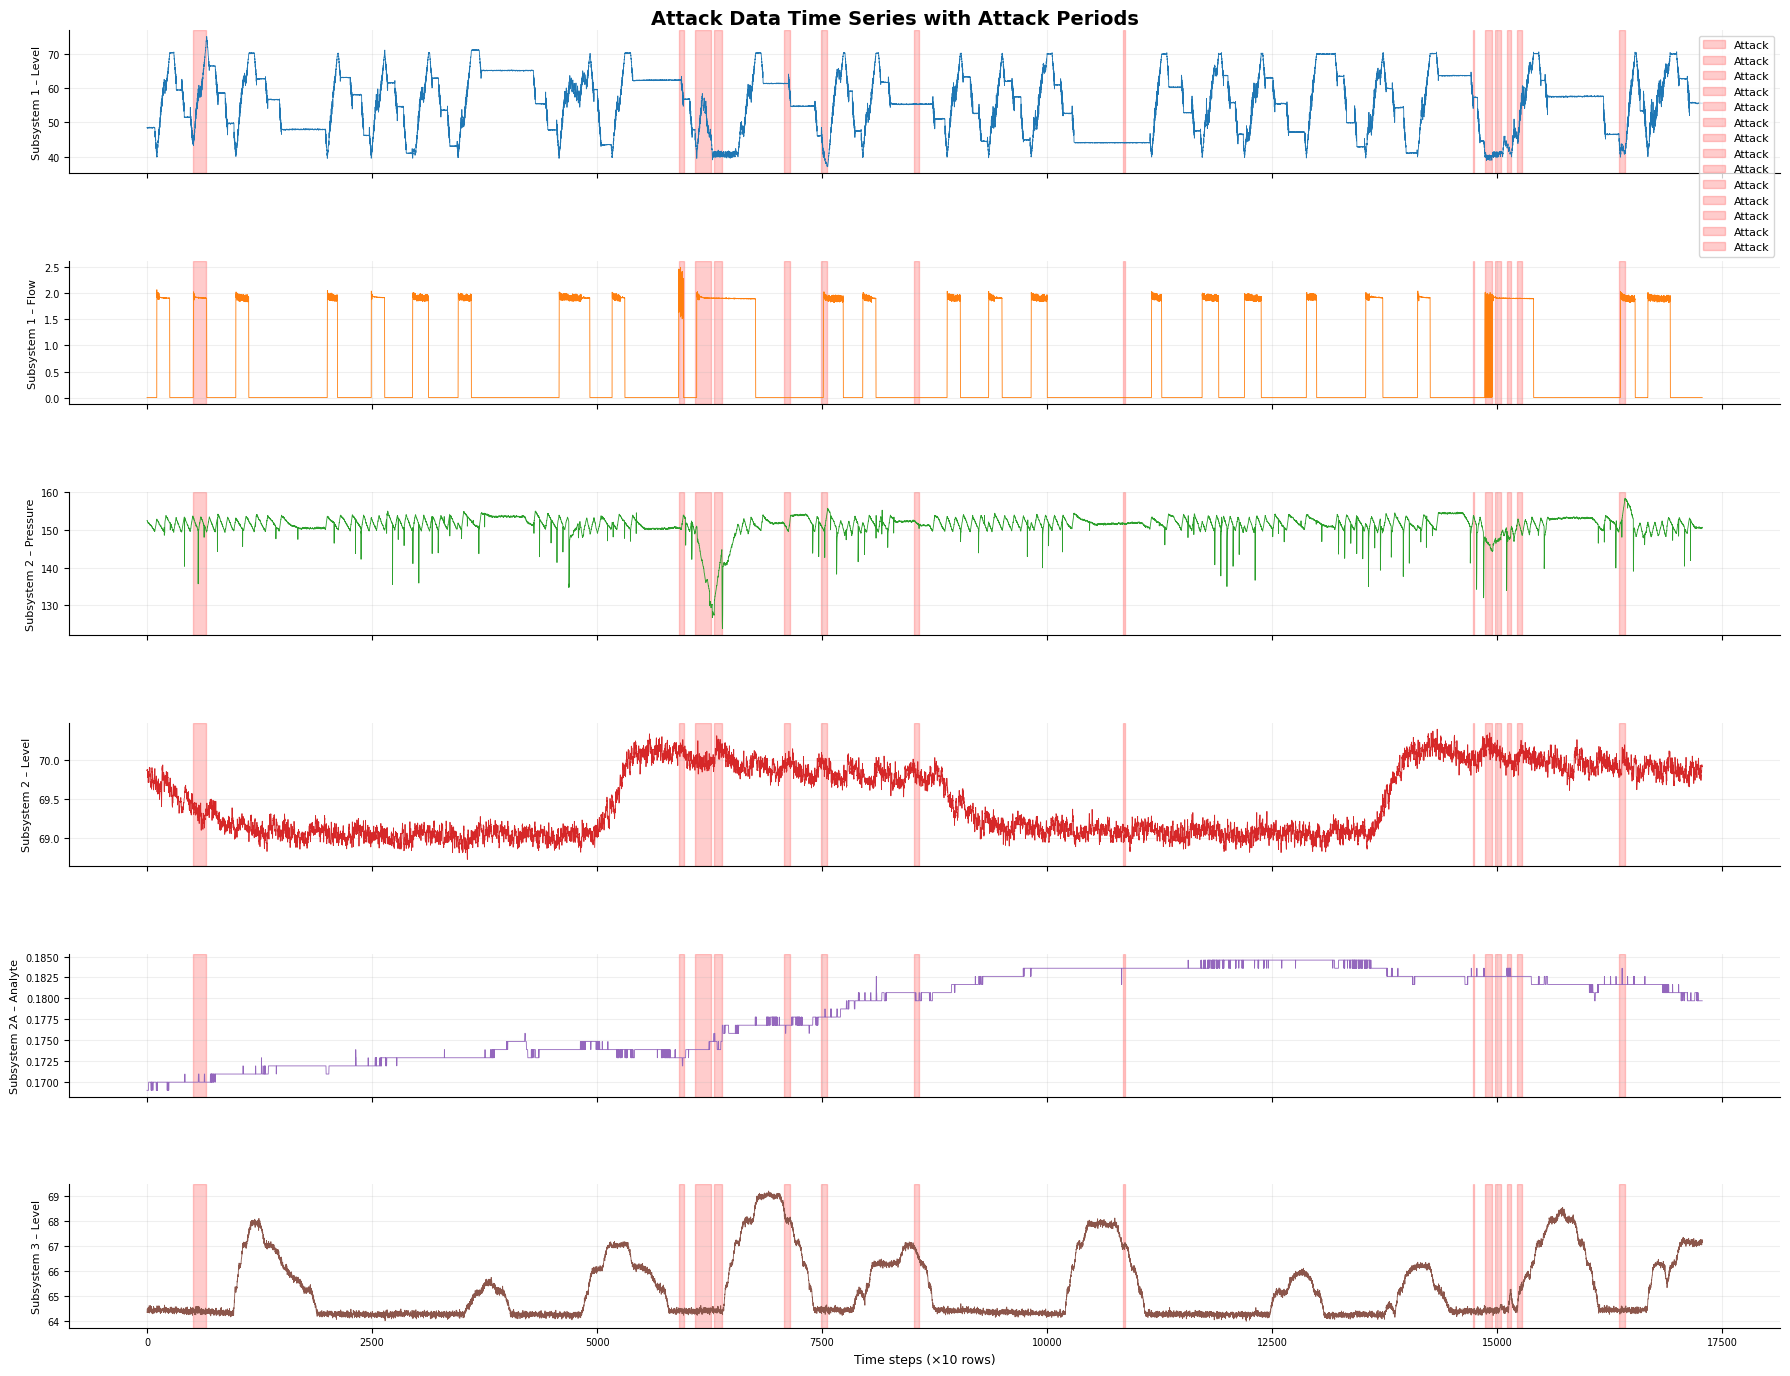

In [6]:
# 1.5 - Attack Data in Time Series and Attack Period Marks
key_sensors = {
    'Subsystem 1 – Level':    '1_LT_001_PV',
    'Subsystem 1 – Flow':     '1_FIT_001_PV',
    'Subsystem 2 – Pressure': '2_PIT_001_PV',
    'Subsystem 2 – Level':    '2_LT_001_PV',
    'Subsystem 2A – Analyte': '2A_AIT_001_PV',
    'Subsystem 3 – Level':    '3_LT_001_PV',
}

label_col = 'Attack LABLE (1:No Attack, -1:Attack)'
point_labels = pd.to_numeric(attack_df[label_col], errors='coerce').map({1: 0, -1: 1}).values
skip_cols = [label_col, 'Date', 'Time']
attack_cols = [c for c in attack_df.columns if c not in skip_cols]
df_at = attack_df[attack_cols].apply(pd.to_numeric, errors='coerce').iloc[::10].reset_index(drop=True)
labels_ds = point_labels[::10]

fig, axes = plt.subplots(len(key_sensors), 1, figsize=(18, 14), sharex=True)
fig.suptitle('Attack Data Time Series with Attack Periods', fontsize=14, fontweight='bold')

for i, (label, col) in enumerate(key_sensors.items()):
    ax = axes[i]
    ax.plot(df_at[col].values, color=plt.cm.tab10.colors[i], linewidth=0.6)
    ax.set_ylabel(label, fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)

    attack_indices = np.where(labels_ds == 1)[0]
    if len(attack_indices):
        breaks = np.where(np.diff(attack_indices) > 1)[0] + 1
        for span in np.split(attack_indices, breaks):
            ax.axvspan(span[0], span[-1], color='red', alpha=0.2, label='Attack' if i == 0 else '')

axes[0].legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('Time steps (×10 rows)', fontsize=9)
plt.tight_layout()
plt.show()

In [7]:
# Data Shape
print(normal_df.shape)
print(attack_df.shape)

(784571, 129)
(172803, 130)


In [8]:
# Find columns with missing values
missing_ratio = normal_df.isna().mean()

# Select columns that have missing values (you can adjust threshold)
fill_cols = missing_ratio[missing_ratio > 0].index.tolist()

print("Columns needing fill:")
print(fill_cols)

Columns needing fill:
['1_AIT_002_PV', '1_AIT_004_PV', '2_LS_001_AL', '2_LS_002_AL', '2_P_001_STATUS', '2_P_002_STATUS', '2B_AIT_004_PV', '3_AIT_004_PV']


#### Data Preparation

In [9]:
# 1. Configuration

WINDOW_SIZE    = 60
STEP_SIZE      = 10
PRETRAIN_EPOCH = 50    # benign pretraining epochs
FINETUNE_EPOCH = 20    # few-shot fine-tuning epochs
BATCH_SIZE     = 64
LR_PRETRAIN    = 1e-3
LR_FINETUNE    = 1e-4  # smaller lr for fine-tuning
FEW_SHOT_PCT   = 0.10  # 10% of attack file for few-shot
RANDOM_SEED    = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
print(f"Device         : {DEVICE}")
print(f"Few-shot split : {int(FEW_SHOT_PCT*100)}% attack for fine-tune / "
      f"{int((1-FEW_SHOT_PCT)*100)}% for test")


drop_cols = ['2_LS_001_AL','2_LS_002_AL','2_P_001_STATUS',
             '2_P_002_STATUS','2B_AIT_002_PV']

normal_df.drop(columns=drop_cols, inplace=True)
attack_df.drop(columns=drop_cols, inplace=True)
attack_df.dropna(axis=0, inplace=True)

fill_cols = ['1_AIT_002_PV','2B_AIT_004_PV','3_AIT_004_PV','1_AIT_004_PV']
normal_df[fill_cols] = normal_df[fill_cols].fillna(method='bfill')

train_cols = [c for c in normal_df.columns if c not in ['Date', 'Time']]
normal_df[train_cols] = normal_df[train_cols].astype(float)
attack_df[train_cols] = attack_df[train_cols].astype(float)

point_labels = pd.to_numeric(
    attack_df['Attack LABLE (1:No Attack, -1:Attack)'], errors='coerce'
).astype(int).map({1: 0, -1: 1}).values
attack_df.drop(columns=['Attack LABLE (1:No Attack, -1:Attack)'], inplace=True)

scaler        = MinMaxScaler()
normal_scaled = scaler.fit_transform(normal_df[train_cols])  # fit on benign
attack_scaled = scaler.transform(attack_df[train_cols])       # transform only

n_features = normal_scaled.shape[1]
print(f"\nNormal (train) : {normal_scaled.shape}")
print(f"Attack (test)  : {attack_scaled.shape}")
print(f"Features       : {n_features}")


Device         : cuda
Few-shot split : 10% attack for fine-tune / 90% for test

Normal (train) : (784571, 122)
Attack (test)  : (172801, 122)
Features       : 122


In [10]:
# 2.  WINDOWING

def create_windows(arr, window_size, step_size):
    windows = []
    for start in range(0, len(arr) - window_size + 1, step_size):
        windows.append(arr[start:start + window_size])
    return np.stack(windows)

# Benign windows — for pretraining
normal_windows     = create_windows(normal_scaled, WINDOW_SIZE, STEP_SIZE)
normal_windows_seq = normal_windows # (N, 60, F)
normal_flat        = normal_windows.reshape(-1, WINDOW_SIZE * n_features)
m                  = WINDOW_SIZE * n_features

# Attack windows — split into few-shot (10%) and test (90%)
attack_windows = create_windows(attack_scaled, WINDOW_SIZE, STEP_SIZE)
label_windows  = create_windows(point_labels.reshape(-1, 1),
                                 WINDOW_SIZE, STEP_SIZE).squeeze(-1)
window_labels  = (label_windows.sum(axis=1) > 0).astype(int)
attack_flat    = attack_windows.reshape(-1, m)

# Stratified split: 10% few-shot / 90% test
fs_idx, test_idx = train_test_split(
    np.arange(len(attack_windows)),
    test_size=(1 - FEW_SHOT_PCT),
    stratify=window_labels,
    random_state=RANDOM_SEED
)

# Few-shot data (10%) — used for fine-tuning
fs_seq    = attack_windows[fs_idx]          # (N_fs, 60, F)
fs_flat   = attack_flat[fs_idx]
fs_labels = window_labels[fs_idx]

# Test data (90%) — used for evaluation only
X_test_seq  = attack_windows[test_idx]      # (N_test, 60, F)
X_test_flat = attack_flat[test_idx]
y_test      = window_labels[test_idx]

actual_anomaly_rate = y_test.mean()
print(f"Benign pretraining windows : {normal_windows.shape}")
print(f"Few-shot windows (10%)     : {fs_seq.shape}  "
      f"— {fs_labels.sum()} anomaly / {(fs_labels==0).sum()} normal")
print(f"Test windows    (90%)      : {X_test_seq.shape}  "
      f"— {y_test.sum()} anomaly / {(y_test==0).sum()} normal")
print(f"Actual anomaly rate (test) : {actual_anomaly_rate:.4f}")


Benign pretraining windows : (78452, 60, 122)
Few-shot windows (10%)     : (1727, 60, 122)  — 108 anomaly / 1619 normal
Test windows    (90%)      : (15548, 60, 122)  — 972 anomaly / 14576 normal
Actual anomaly rate (test) : 0.0625


### Threshold Definition

In [11]:
# 3 ROC-OPTIMAL THRESHOLD

def best_threshold(scores, y_true):
    """Sweep all thresholds and pick one that maximises F1."""
    _, _, thresholds = roc_curve(y_true, scores)
    best_t, best_f1 = thresholds[0], 0.0
    for t in thresholds:
        yp  = (scores >= t).astype(int)
        f1v = f1_score(y_true, yp, pos_label=1, zero_division=0)
        if f1v > best_f1:
            best_f1 = f1v
            best_t  = t
    return best_t

def evaluate(name, scores, y_true):
    thresh = best_threshold(scores, y_true)
    y_pred = (scores >= thresh).astype(int)
    auc    = roc_auc_score(y_true, scores)
    f1     = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    rec    = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    prec   = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    acc    = (y_pred == y_true).mean()
    print(f"\n{'='*54}\n  {name}\n{'='*54}")
    print(f"  Threshold (ROC-optimal) = {thresh:.6f}")
    print(classification_report(y_true, y_pred, digits=4))
    return dict(name=name, f1=f1, recall=rec, precision=prec,
                auc=auc, acc=acc, y_pred=y_pred,
                scores=scores, thresh=thresh)

#### Model Definitions

In [13]:
#  MODEL DEFINITIONS
# -------------------------------------------------------

# -- IF ------------------------------------------------
class CERELayer(nn.Module): # random projection layer
    def __init__(self, input_dim, output_dim, r):
        super().__init__()
        self.input_dim, self.output_dim, self.r = input_dim, output_dim, r
        self.W0 = nn.Parameter(torch.randn(input_dim, output_dim), requires_grad=False)
        self.p  = nn.Parameter(torch.randn(r, input_dim),          requires_grad=False)
        self.q  = nn.Parameter(torch.randn(r, output_dim),         requires_grad=False)

    def forward(self, X):
        b      = X.size(0)
        X_exp  = X.unsqueeze(1).expand(-1, self.r, -1)
        p_exp  = self.p.unsqueeze(0).expand(b, -1, -1)
        Xp     = X_exp * p_exp
        M_flat = Xp.view(b * self.r, self.input_dim) @ self.W0
        M      = M_flat.view(b, self.r, self.output_dim)
        q_exp  = self.q.unsqueeze(0).expand(b, -1, -1)
        return M * q_exp

class iNode:
    def __init__(self, depth=0):
        self.left = self.right = None
        self.split_dim = self.split_val = None
        self.depth = depth; self.is_leaf = False; self.size = 0

class iTree:
    def __init__(self, data): self.root = self._build(data, 0)
    def _build(self, data, depth):
        n, mm = data.shape; node = iNode(depth); node.size = n
        if n <= 1: node.is_leaf = True; return node
        q = np.random.randint(mm); vals = data[:, q]
        mn, mx = vals.min(), vals.max()
        if mn == mx: node.is_leaf = True; return node
        eta = np.random.uniform(mn, mx)
        node.split_dim, node.split_val = q, eta
        left = data[vals <= eta]; right = data[vals > eta]
        if len(left) == 0 or len(right) == 0:
            node.is_leaf = True; return node
        node.left  = self._build(left,  depth + 1)
        node.right = self._build(right, depth + 1)
        return node
    def path_dev(self, x):
        node, h, dev = self.root, 0, []
        while node and not node.is_leaf:
            q, eta = node.split_dim, node.split_val
            h += 1; dev.append(abs(x[q] - eta))
            node = node.left if x[q] <= eta else node.right
        return h, np.mean(dev) if dev else 0

class iForestDEAS:
    def __init__(self, n_trees=20, subsample_size=64):
        self.n_trees = n_trees; self.subsample = subsample_size; self.trees = []
        self.c = lambda n: 2*(np.log(n-1)+0.5772156649)-2*(n-1)/n if n > 1 else 0
    def fit(self, X):
        n = X.shape[0]; self.trees = []
        for _ in range(self.n_trees):
            idx = np.random.choice(n, min(n, self.subsample), replace=False)
            self.trees.append(iTree(X[idx]))
    def score(self, X):
        scores = []
        for x in X:
            depths, devs = zip(*(t.path_dev(x) for t in self.trees))
            Eh, Eg = np.mean(depths), np.mean(devs)
            scores.append((2**(-Eh/self.c(self.subsample))) * Eg)
        return np.array(scores)

class IFCERE:
    def __init__(self, input_dim, d=32, hidden_dim=32, r=30,
                 n_trees=100, subsample_size=128):
        self.cere    = CERELayer(input_dim, hidden_dim, r)
        self.fc      = nn.Linear(hidden_dim, d)
        nn.init.normal_(self.fc.weight)
        self.if_deas = iForestDEAS(n_trees, subsample_size)
        self.r, self.hidden_dim = r, hidden_dim

    def fit(self, X):
        Zh      = self.cere(torch.from_numpy(X.astype(np.float32)))
        n       = self.r * X.shape[0]
        Zh_flat = Zh.view(n, self.hidden_dim).detach().numpy()
        Zd      = self.fc(torch.from_numpy(Zh_flat)).detach().numpy()
        self.if_deas.fit(Zd)

    def score(self, X):
        Zh      = self.cere(torch.from_numpy(X.astype(np.float32)))
        n       = self.r * X.shape[0]
        Zh_flat = Zh.view(n, self.hidden_dim).detach().numpy()
        Zd      = self.fc(torch.from_numpy(Zh_flat)).detach().numpy()
        s       = self.if_deas.score(Zd)
        return s.reshape(-1, self.r).mean(axis=1)


# -- LSTM Autoencoder ----------------------------------------
class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features, hidden_dim=128, latent_dim=64, n_layers=2):
        super().__init__()
        self.encoder   = nn.LSTM(n_features, hidden_dim, n_layers,
                                 batch_first=True, dropout=0.2)
        self.latent    = nn.Linear(hidden_dim, latent_dim)
        self.decode_fc = nn.Linear(latent_dim, hidden_dim)
        self.decoder   = nn.LSTM(hidden_dim, n_features, n_layers,
                                 batch_first=True, dropout=0.2)

    def forward(self, x):
        _, (h, _) = self.encoder(x)
        z         = self.latent(h[-1])
        dec_in    = self.decode_fc(z).unsqueeze(1).repeat(1, x.size(1), 1)
        out, _    = self.decoder(dec_in)
        return out


# -- Transformer Autoencoder ------------------------------
class TransformerAutoencoder(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=4,
                 num_layers=2, dim_ff=256):
        super().__init__()
        self.input_proj  = nn.Linear(n_features, d_model)
        self.output_proj = nn.Linear(d_model, n_features)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_ff, dropout=0.1,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        dec_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_ff, dropout=0.1,
            batch_first=True
        )
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=num_layers)

    def forward(self, x):
        src    = self.input_proj(x)
        memory = self.encoder(src)
        out    = self.decoder(src, memory)
        return self.output_proj(out)



#  Train Helper Functions ------------------------------------
# ------------------------------------------------------------
def pretrain_ae(model, X_seq, epochs, batch_size=BATCH_SIZE,
                lr=LR_PRETRAIN, label="AE"):
    """Phase 1: train on benign data only -- reconstruction loss"""
    optim   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched   = torch.optim.lr_scheduler.StepLR(optim, step_size=20, gamma=0.5)
    loss_fn = nn.MSELoss()
    ds      = TensorDataset(torch.FloatTensor(X_seq))
    loader  = DataLoader(ds, batch_size=batch_size, shuffle=True)
    model.train()
    for ep in range(epochs):
        total = 0
        for (xb,) in loader:
            xb = xb.to(DEVICE)
            optim.zero_grad()
            loss = loss_fn(model(xb), xb)
            loss.backward(); optim.step()
            total += loss.item()
        sched.step()
        if (ep + 1) % 10 == 0:
            print(f"  [{label} pretrain] ep {ep+1}/{epochs}  "
                  f"loss={total/len(loader):.6f}")
    return model

def finetune_ae(model, X_seq, y, epochs, batch_size=BATCH_SIZE,
                lr=LR_FINETUNE, label="AE"):
    """
    Phase 2: few-shot fine-tuning.
    - Normal windows (y=0) → minimise reconstruction error (same as before)
    - Anomaly windows (y=1) → MAXIMISE reconstruction error (push anomalies away)
    This sharpens the boundary between normal and anomalous.
    """
    optim   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    loss_fn = nn.MSELoss(reduction='none')
    ds      = TensorDataset(torch.FloatTensor(X_seq),
                             torch.FloatTensor(y))
    loader  = DataLoader(ds, batch_size=batch_size, shuffle=True)
    model.train()
    for ep in range(epochs):
        total = 0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optim.zero_grad()
            out      = model(xb)
            # per-sample mean recon error: (B,)
            recon    = loss_fn(out, xb).mean(dim=(1, 2))
            # normal: minimise  |  anomaly: maximise (negate)
            signs    = torch.where(yb == 0,
                                   torch.ones_like(yb),
                                   -torch.ones_like(yb))
            loss     = (signs * recon).mean()
            loss.backward(); optim.step()
            total += loss.item()
        if (ep + 1) % 5 == 0:
            print(f"  [{label} finetune] ep {ep+1}/{epochs}  "
                  f"loss={total/len(loader):.6f}")
    return model

def score_ae(model, X_seq):
    """Anomaly score = mean reconstruction error per window."""
    model.eval()
    with torch.no_grad():
        x   = torch.FloatTensor(X_seq).to(DEVICE)
        out = model(x)
        err = ((out - x) ** 2).mean(dim=(1, 2))
    return err.cpu().numpy()

### Model Training

In [14]:
#  TRAIN ALL MODELS
# ------------------------------------------------------------
results = []

# -- Model 1: IF (unsupervised) --------
print("\n" + "─"*54)
print("[1/4] Isolation Forest (unsupervised)")
print("─"*54)
dif = IFCERE(input_dim=m)
dif.fit(normal_flat)
scores_dif = dif.score(X_test_flat)
results.append(evaluate("Isolation Forest", scores_dif, y_test))

# -- Model 2: LSTM AE (unsupervised) --
print("\n" + "─"*54)
print("[2/4] LSTM Autoencoder (unsupervised)")
print("─"*54)
lstm_ae = LSTMAutoencoder(n_features).to(DEVICE)
lstm_ae = pretrain_ae(lstm_ae, normal_windows_seq,
                      epochs=PRETRAIN_EPOCH, label="LSTM-AE")
scores_lstm = score_ae(lstm_ae, X_test_seq)
results.append(evaluate("LSTM-AE (unsupervised)", scores_lstm, y_test))

# -- Model 3: LSTM AE + few-shot fine-tuning || 10% A -----------------
print("\n" + "─"*54)
print("[3/4] LSTM AE (semi-supervised)")
print("─"*54)
lstm_fs = LSTMAutoencoder(n_features).to(DEVICE)
# Phase 1 — pretrain on benign
lstm_fs = pretrain_ae(lstm_fs, normal_windows_seq,
                      epochs=PRETRAIN_EPOCH, label="LSTM-FS pretrain")
# Phase 2 — fine-tune with 10% labeled attack
lstm_fs = finetune_ae(lstm_fs, fs_seq, fs_labels,
                      epochs=FINETUNE_EPOCH, label="LSTM-FS finetune")
scores_lstm_fs = score_ae(lstm_fs, X_test_seq)
results.append(evaluate("LSTM-AE (semi-supervised)", scores_lstm_fs, y_test))

# -- Model 4: Transformer AE + few-shot fine-tuning || 10% A--------
print("\n" + "─"*54)
print("[4/4] Transformer AE (semi-supervised)")
print("─"*54)
trans_fs = TransformerAutoencoder(n_features).to(DEVICE)
# Phase 1 — pretrain on benign
trans_fs = pretrain_ae(trans_fs, normal_windows_seq,
                       epochs=PRETRAIN_EPOCH, label="Trans-FS pretrain")
# Phase 2 — fine-tune with 10% labeled attack
trans_fs = finetune_ae(trans_fs, fs_seq, fs_labels,
                       epochs=FINETUNE_EPOCH, label="Trans-FS finetune")
scores_trans_fs = score_ae(trans_fs, X_test_seq)
results.append(evaluate("Transformer-AE (semi-supervised)", scores_trans_fs, y_test))



──────────────────────────────────────────────────────
[1/4] Isolation Forest (unsupervised)
──────────────────────────────────────────────────────

  Isolation Forest
  Threshold (ROC-optimal) = 117.307154
              precision    recall  f1-score   support

           0     0.9581    0.9988    0.9780     14576
           1     0.9490    0.3447    0.5057       972

    accuracy                         0.9579     15548
   macro avg     0.9535    0.6717    0.7418     15548
weighted avg     0.9575    0.9579    0.9485     15548


──────────────────────────────────────────────────────
[2/4] LSTM Autoencoder (unsupervised)
──────────────────────────────────────────────────────
  [LSTM-AE pretrain] ep 10/50  loss=0.005158
  [LSTM-AE pretrain] ep 20/50  loss=0.004752
  [LSTM-AE pretrain] ep 30/50  loss=0.003979
  [LSTM-AE pretrain] ep 40/50  loss=0.003439
  [LSTM-AE pretrain] ep 50/50  loss=0.002849

  LSTM-AE (unsupervised)
  Threshold (ROC-optimal) = 0.021193
              precision    r

### Model Evaluations + Visualizations

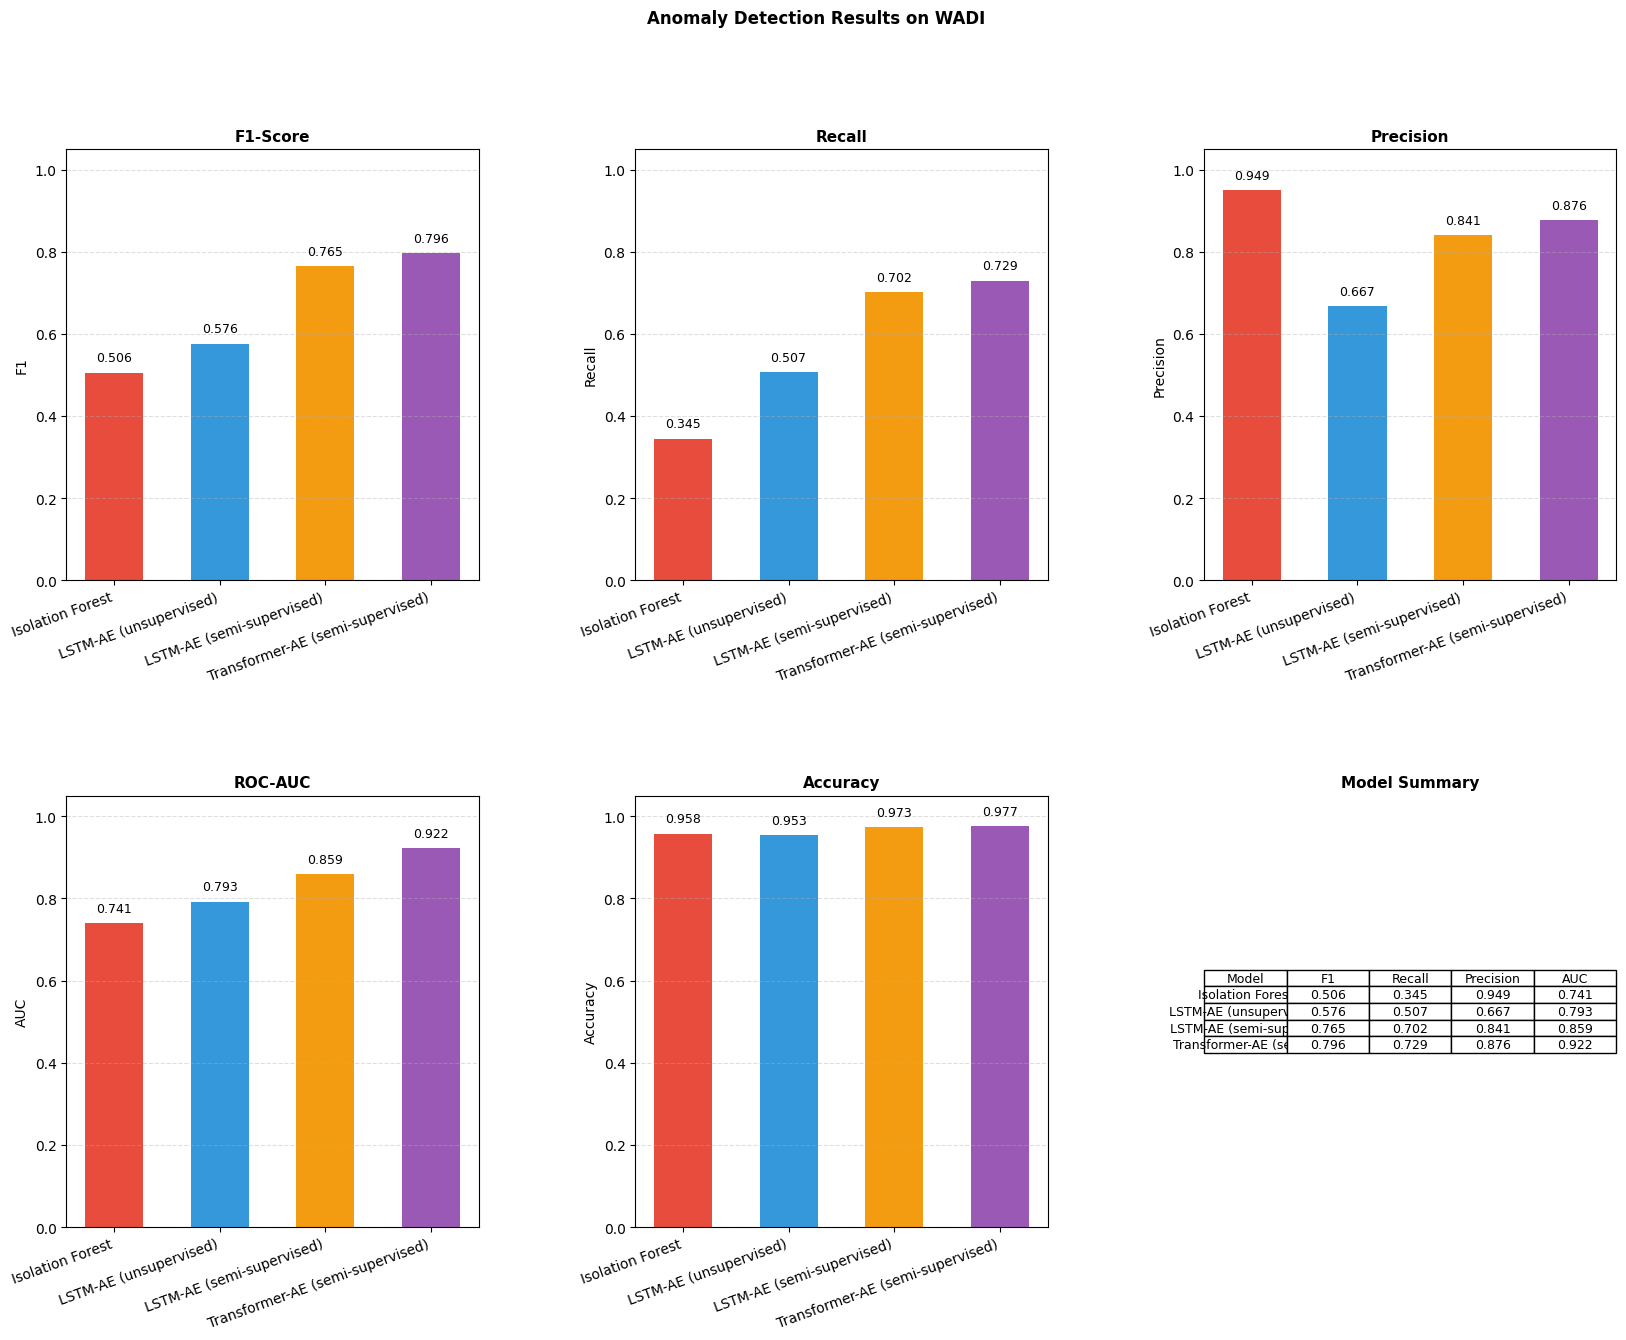

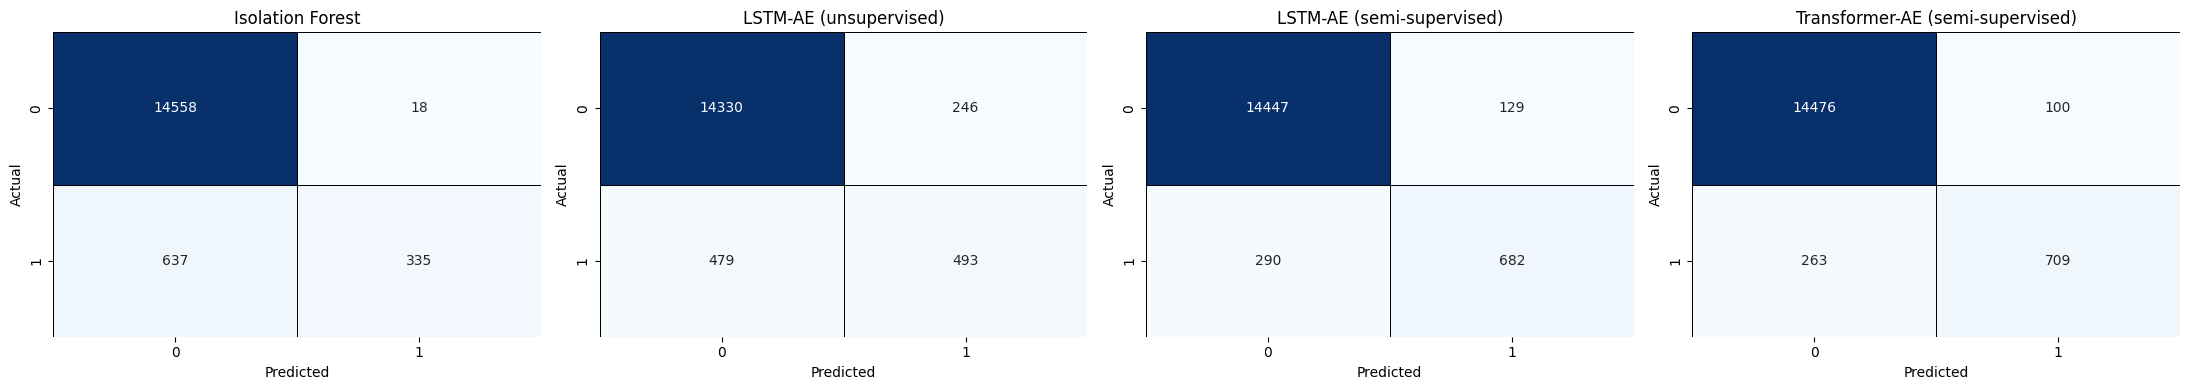


MODEL PERFORMANCE SUMMARY
Model                          Training                         F1   Recall     Prec      AUC
----------------------------------------------------------------------
Isolation Forest               benign only                  0.5057   0.3447   0.9490   0.7409
LSTM-AE (unsupervised)         benign only                  0.5763   0.5072   0.6671   0.7926
LSTM-AE (semi-supervised)      benign + 10% attack          0.7650   0.7016   0.8409   0.8589
Transformer-AE (semi-supervise benign + 10% attack          0.7962   0.7294   0.8764   0.9224

Best Performance: Transformer-AE (semi-supervised)  |  F1 = 0.7962


In [15]:
# PLOTS
# ============================================================
names      = [r["name"]      for r in results]
f1s        = [r["f1"]        for r in results]
recalls    = [r["recall"]    for r in results]
precisions = [r["precision"] for r in results]
aucs       = [r["auc"]       for r in results]
accs       = [r["acc"]       for r in results]
palette    = ["#e74c3c", "#3498db", "#f39c12", "#9b59b6"]

fig = plt.figure(figsize=(20, 14), facecolor="white")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.38)

def bar_ax(ax, values, title, ylabel):
    bars = ax.bar(range(len(names)), values, color=palette, width=0.55)
    ax.set_facecolor("white")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=20, ha="right")
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.02,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)

bar_ax(fig.add_subplot(gs[0, 0]), f1s, "F1-Score", "F1")
bar_ax(fig.add_subplot(gs[0, 1]), recalls, "Recall", "Recall")
bar_ax(fig.add_subplot(gs[0, 2]), precisions, "Precision", "Precision")
bar_ax(fig.add_subplot(gs[1, 0]), aucs, "ROC-AUC", "AUC")
bar_ax(fig.add_subplot(gs[1, 1]), accs, "Accuracy", "Accuracy")

# Summary table
ax_t = fig.add_subplot(gs[1, 2])
ax_t.set_facecolor("white")
ax_t.axis("off")
ax_t.set_title("Model Summary", fontsize=11, fontweight="bold")

rows = [[r["name"][:22],
         f"{r['f1']:.3f}",
         f"{r['recall']:.3f}",
         f"{r['precision']:.3f}",
         f"{r['auc']:.3f}"]
        for r in results]

tbl = ax_t.table(
    cellText=rows,
    colLabels=["Model", "F1", "Recall", "Precision", "AUC"],
    loc="center",
    cellLoc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9)

for cell in tbl.get_celld().values():
    cell.set_facecolor("white")
    cell.set_edgecolor("black")

fig.suptitle(
    "Anomaly Detection Results on WADI",
    fontsize=12,
    fontweight="bold"
)

plt.savefig("model_comparison_clean.png", dpi=150, bbox_inches="tight")
plt.show()

# CONFUSION MATRICES
# ============================================================
fig2, axes = plt.subplots(1, 4, figsize=(22, 4), facecolor="white")

for ax, r, c in zip(axes, results, palette):
    cm = confusion_matrix(y_test, r["y_pred"])

    sns.heatmap(cm,
                annot=True,
                fmt="d",
                ax=ax,
                cmap="Blues",
                linewidths=0.5,
                linecolor="black",
                cbar=False)

    ax.set_facecolor("white")
    ax.set_title(r["name"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrices_clean.png", dpi=150, bbox_inches="tight")
plt.show()

# SUMMARY
# ============================================================
print("\n" + "="*70)
print("MODEL PERFORMANCE SUMMARY")
print("="*70)
print(f"{'Model':<30} {'Training':<28} {'F1':>6} {'Recall':>8} {'Prec':>8} {'AUC':>8}")
print("-"*70)

train_info = [
    "benign only",
    "benign only",
    "benign + 10% attack",
    "benign + 10% attack",
]

for r, ti in zip(results, train_info):
    print(f"{r['name'][:30]:<30} {ti:<28} {r['f1']:>6.4f} "
          f"{r['recall']:>8.4f} {r['precision']:>8.4f} {r['auc']:>8.4f}")

print("="*70)

best = max(results, key=lambda x: x["f1"])
print(f"\nBest Performance: {best['name']}  |  F1 = {best['f1']:.4f}")

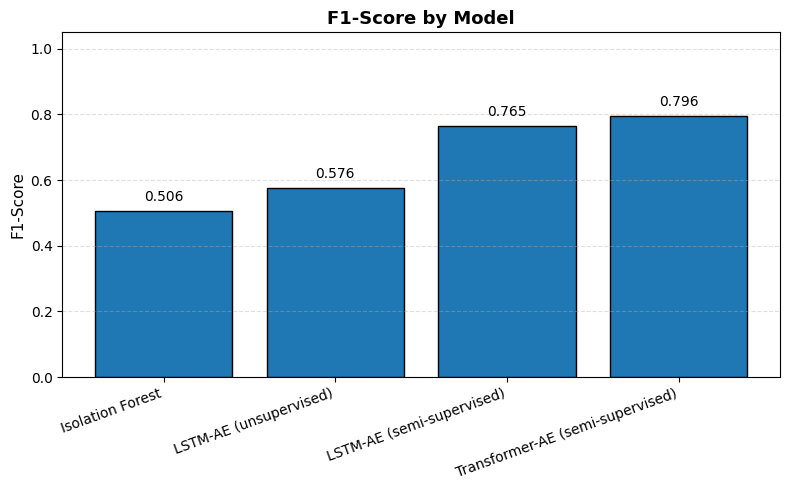

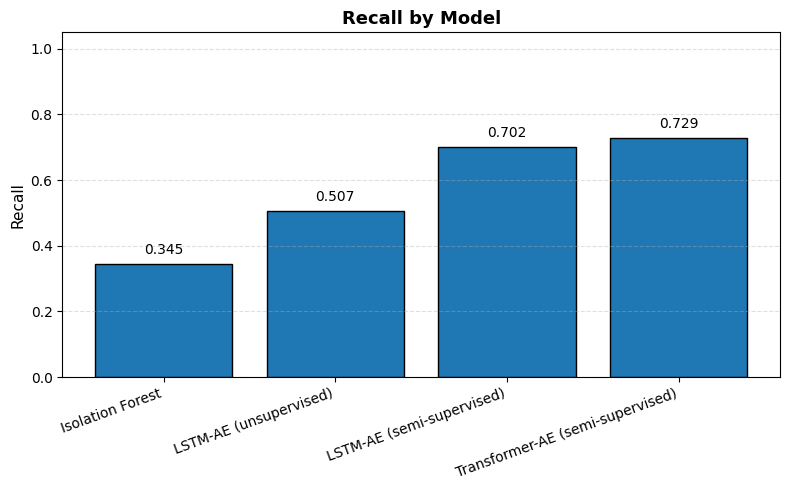

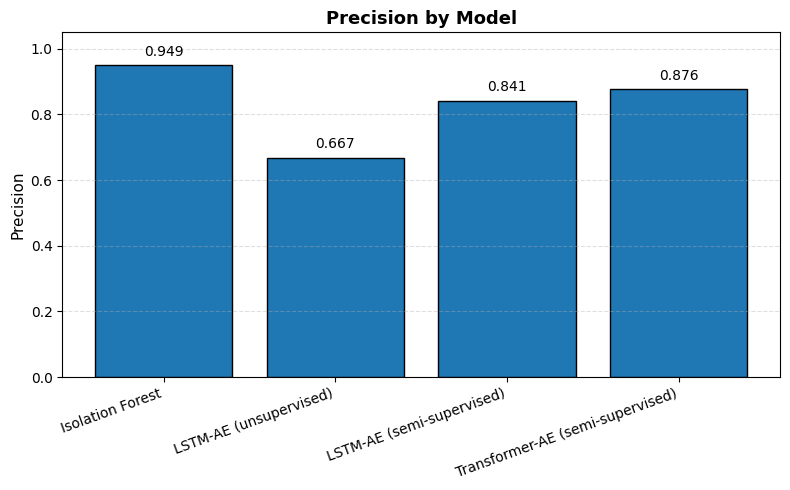

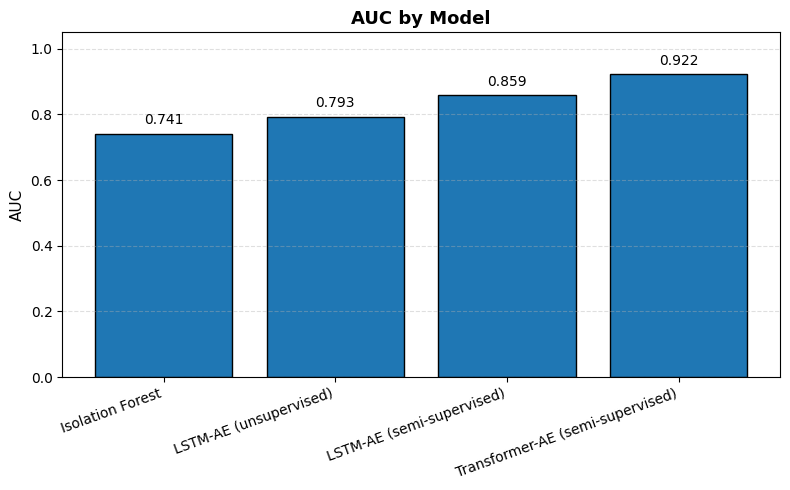

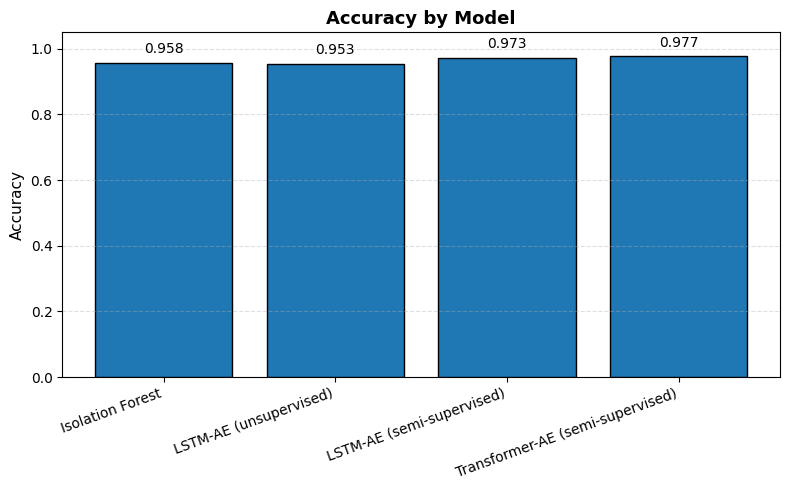

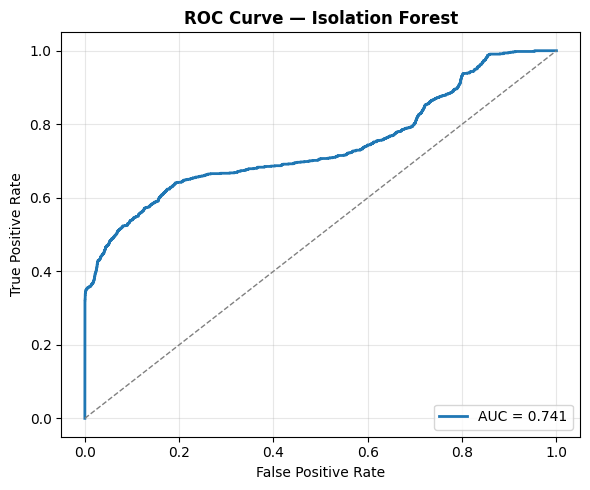

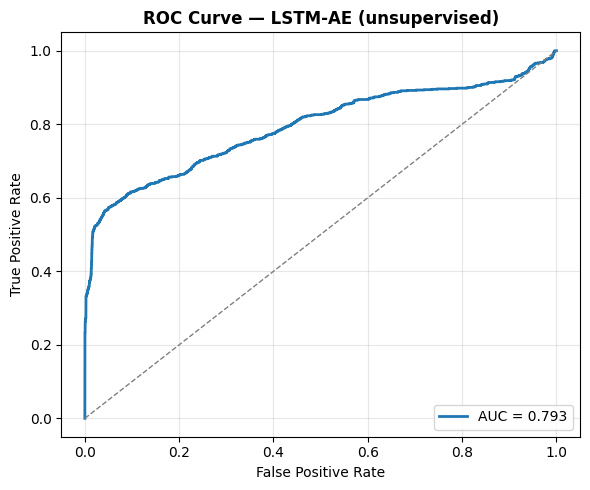

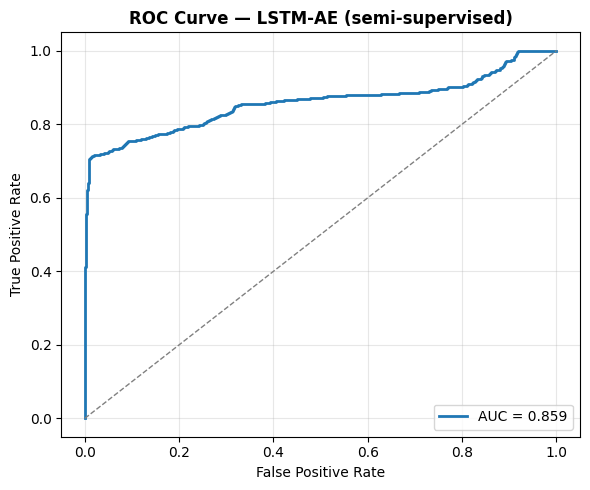

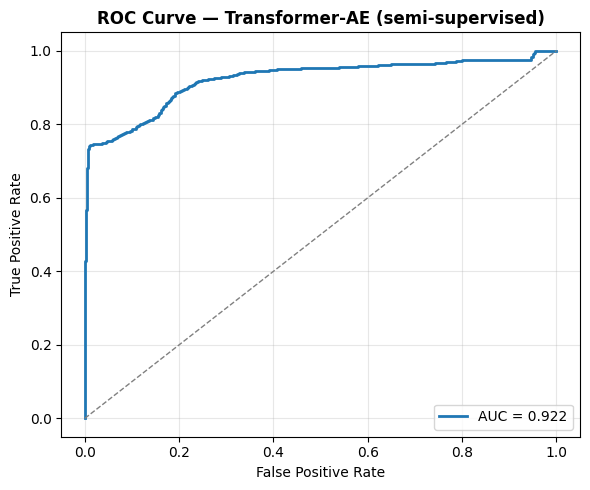

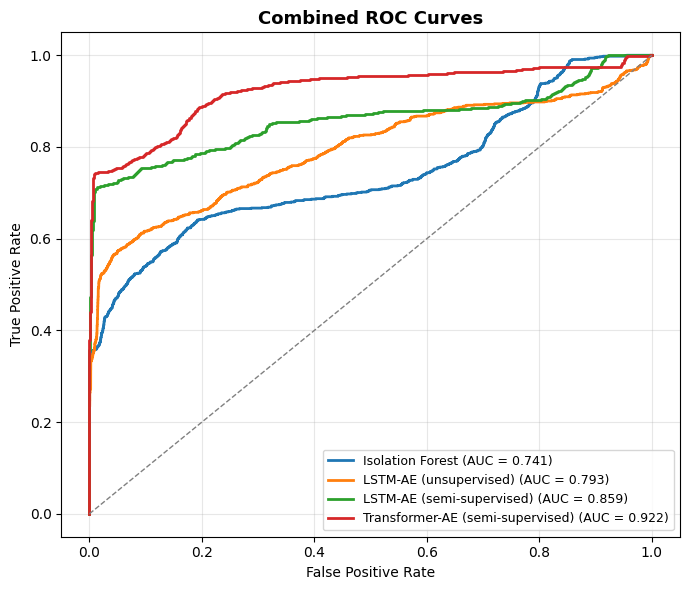

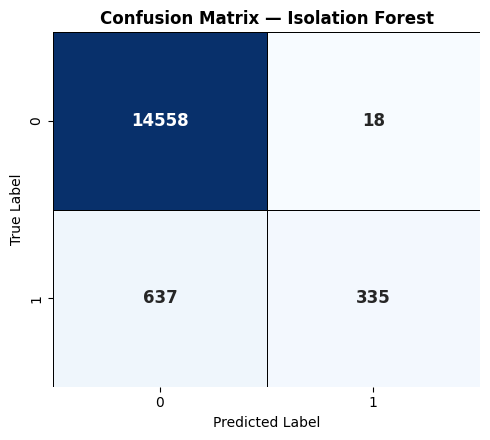

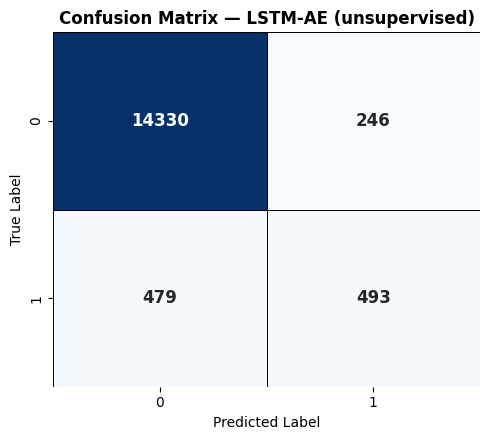

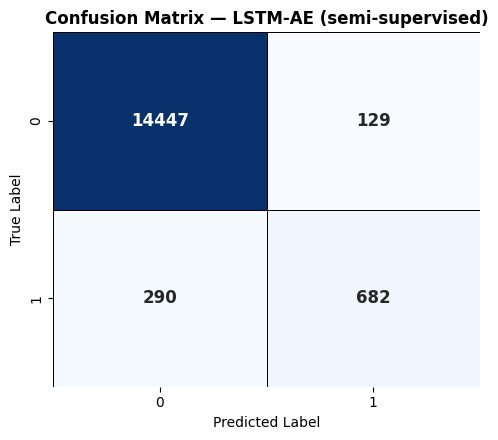

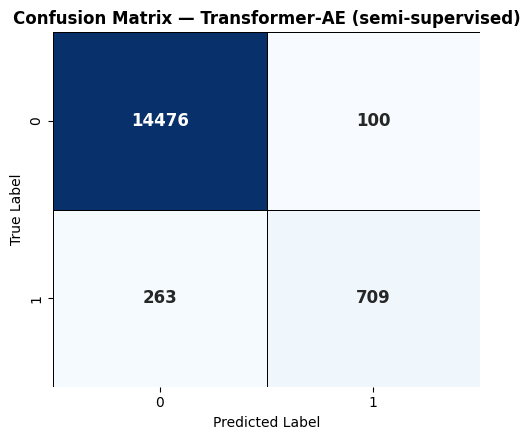


MODEL PERFORMANCE SUMMARY
Model                          Training                         F1   Recall     Prec      AUC
----------------------------------------------------------------------
Isolation Forest               benign only                  0.5057   0.3447   0.9490   0.7409
LSTM-AE (unsupervised)         benign only                  0.5763   0.5072   0.6671   0.7926
LSTM-AE (semi-supervised)      benign + 10% attack          0.7650   0.7016   0.8409   0.8589
Transformer-AE (semi-supervise benign + 10% attack          0.7962   0.7294   0.8764   0.9224

Best model: Transformer-AE (semi-supervised)  |  F1 = 0.7962


In [16]:
# PLOTS — Model Wise
# ============================================================
import os
from sklearn.metrics import roc_curve, auc, confusion_matrix

os.makedirs("plots_clean", exist_ok=True)

names      = [r["name"]      for r in results]
f1s        = [r["f1"]        for r in results]
recalls    = [r["recall"]    for r in results]
precisions = [r["precision"] for r in results]
aucs       = [r["auc"]       for r in results]
accs       = [r["acc"]       for r in results]

# -----------------------------
# Helper: clean white bar plot
# -----------------------------
def save_metric_bar(values, labels, title, ylabel, filename):
    plt.figure(figsize=(8, 5), facecolor="white")
    ax = plt.gca()
    ax.set_facecolor("white")

    bars = ax.bar(range(len(labels)), values, edgecolor="black")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=20, ha="right")
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f"{val:.3f}",
                ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.savefig(f"plots_clean/{filename}", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

# -----------------------------
# Separate metric plots
# -----------------------------
save_metric_bar(f1s, names, "F1-Score by Model", "F1-Score", "f1_scores.png")
save_metric_bar(recalls, names, "Recall by Model", "Recall", "recall_scores.png")
save_metric_bar(precisions, names, "Precision by Model", "Precision", "precision_scores.png")
save_metric_bar(aucs, names, "AUC by Model", "AUC", "auc_scores.png")
save_metric_bar(accs, names, "Accuracy by Model", "Accuracy", "accuracy_scores.png")

# -----------------------------
# ROC curve for each approach
# -----------------------------
for r in results:
    fpr, tpr, _ = roc_curve(y_test, r["scores"])
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5), facecolor="white")
    ax = plt.gca()
    ax.set_facecolor("white")

    plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)

    plt.title(f"ROC Curve — {r['name']}", fontsize=12, fontweight="bold")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)

    fname = r["name"].replace(" ", "_").replace("+", "plus").replace("/", "_")
    plt.tight_layout()
    plt.savefig(f"plots_clean/roc_{fname}.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

# -----------------------------
# Combined ROC plot
# -----------------------------
plt.figure(figsize=(7, 6), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")

for r in results:
    fpr, tpr, _ = roc_curve(y_test, r["scores"])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f"{r['name']} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
plt.title("Combined ROC Curves", fontsize=13, fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("plots_clean/roc_combined.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# -----------------------------
# Confusion matrix
# -----------------------------
for r in results:
    cm = confusion_matrix(y_test, r["y_pred"])

    plt.figure(figsize=(5, 4.5), facecolor="white")
    ax = plt.gca()
    ax.set_facecolor("white")

    sns.heatmap(cm,
                annot=True,
                fmt="d",
                cmap="Blues",
                cbar=False,
                linewidths=0.5,
                linecolor="black",
                annot_kws={"size": 12, "weight": "bold"})

    plt.title(f"Confusion Matrix — {r['name']}", fontsize=12, fontweight="bold")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()

    fname = r["name"].replace(" ", "_").replace("+", "plus").replace("/", "_")
    plt.savefig(f"plots_clean/cm_{fname}.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "="*70)
print("MODEL PERFORMANCE SUMMARY")
print("="*70)
print(f"{'Model':<30} {'Training':<28} {'F1':>6} {'Recall':>8} {'Prec':>8} {'AUC':>8}")
print("-"*70)

train_info = [
    "benign only",
    "benign only",
    "benign + 10% attack",
    "benign + 10% attack",
]

for r, ti in zip(results, train_info):
    print(f"{r['name'][:30]:<30} {ti:<28} {r['f1']:>6.4f} "
          f"{r['recall']:>8.4f} {r['precision']:>8.4f} {r['auc']:>8.4f}")

print("="*70)

best = max(results, key=lambda x: x["f1"])
print(f"\nBest model: {best['name']}  |  F1 = {best['f1']:.4f}")

## Anomaly Score and Reconstruction Score Plots

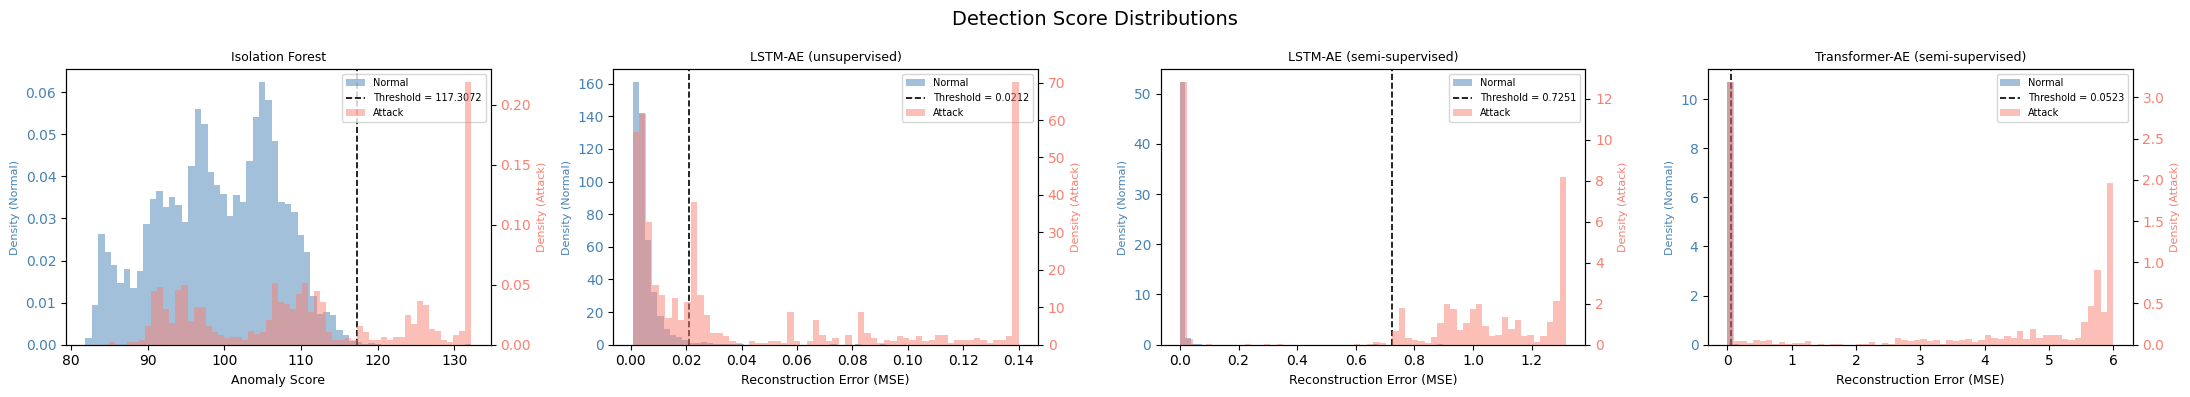

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(22, 4))
fig.suptitle("Detection Score Distributions", fontsize=14)

models = [
    ("Isolation Forest",   scores_dif,      y_test, "Anomaly Score"),
    ("LSTM-AE (unsupervised)",     scores_lstm,     y_test, "Reconstruction Error (MSE)"),
    ("LSTM-AE (semi-supervised)",        scores_lstm_fs,  y_test, "Reconstruction Error (MSE)"),
    ("Transformer-AE (semi-supervised)", scores_trans_fs, y_test, "Reconstruction Error (MSE)"),
]

for ax, (name, scores, labels, xlabel) in zip(axes, models):
    normal_scores = scores[labels == 0]
    attack_scores = scores[labels == 1]

    clip_val = np.percentile(scores, 99)
    bins = 60

    # Primary axis — normal distribution
    ax.hist(normal_scores.clip(max=clip_val), bins=bins,
            alpha=0.5, color="steelblue", label="Normal", density=True)
    ax.set_ylabel("Density (Normal)", fontsize=8, color="steelblue")
    ax.tick_params(axis='y', labelcolor="steelblue")

    # Secondary axis — attack distribution
    ax2 = ax.twinx()
    ax2.hist(attack_scores.clip(max=clip_val), bins=bins,
             alpha=0.5, color="salmon", label="Attack", density=True)
    ax2.set_ylabel("Density (Attack)", fontsize=8, color="salmon")
    ax2.tick_params(axis='y', labelcolor="salmon")

    # Threshold on primary axis
    thresh = results[[r["name"] for r in results].index(name)]["thresh"]
    ax.axvline(thresh, color="black", linestyle="--",
               linewidth=1.2, label=f"Threshold = {thresh:.4f}")

    ax.set_title(name, fontsize=9)
    ax.set_xlabel(xlabel, fontsize=9)

    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7)

plt.tight_layout()
plt.savefig("detection_score_distributions.png", dpi=150)
plt.show()

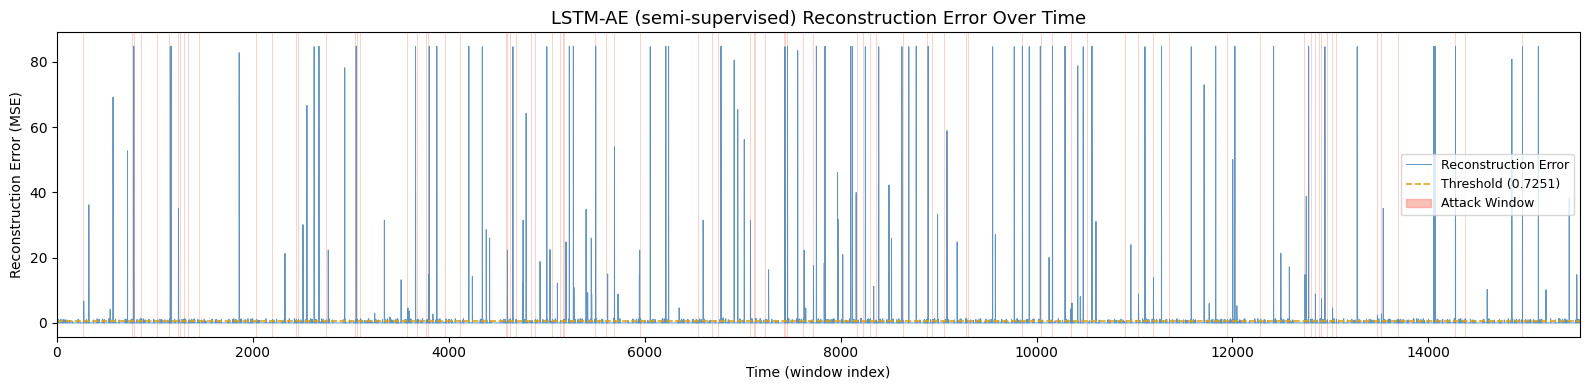

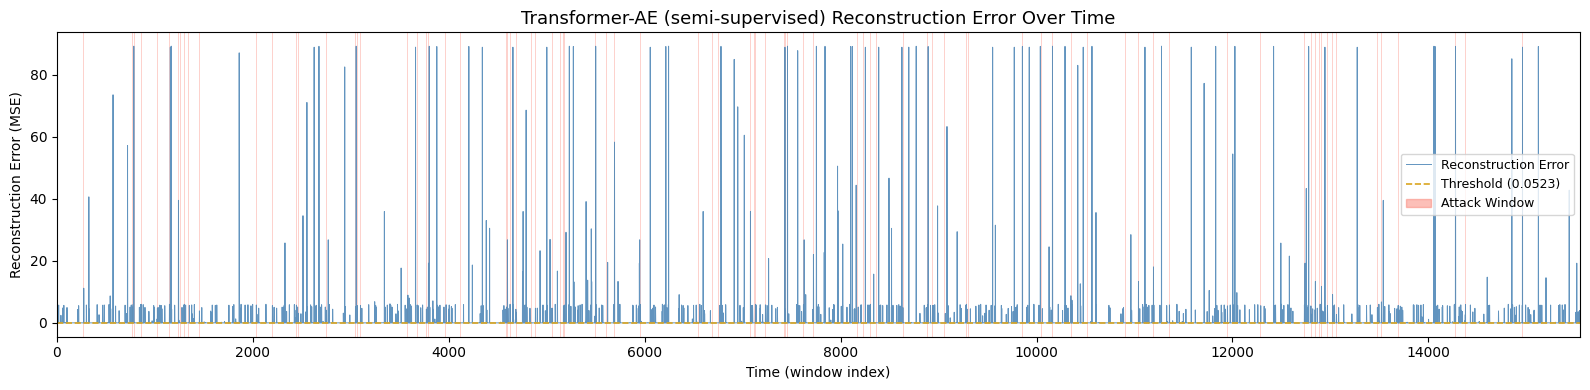

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_reconstruction_over_time(scores, labels, thresh, title="Autoencoder Reconstruction Error Over Time"):
    fig, ax = plt.subplots(figsize=(16, 4))

    time_axis = np.arange(len(scores))

    # Reconstruction error line
    ax.plot(time_axis, scores, color="steelblue", linewidth=0.7,
            alpha=0.85, label="Reconstruction Error")

    # Threshold line
    ax.axhline(thresh, color="goldenrod", linestyle="--",
               linewidth=1.2, label=f"Threshold ({thresh:.4f})")

    # Shade attack windows
    in_attack = False
    start = 0
    for i, lbl in enumerate(labels):
        if lbl == 1 and not in_attack:
            start = i
            in_attack = True
        elif lbl == 0 and in_attack:
            ax.axvspan(start, i, color="salmon", alpha=0.35, linewidth=0)
            in_attack = False
    if in_attack:  # close final attack if it runs to the end
        ax.axvspan(start, len(labels), color="salmon", alpha=0.35, linewidth=0)

    # Legend
    attack_patch = mpatches.Patch(color="salmon", alpha=0.5, label="Attack Window")
    ax.legend(handles=[ax.lines[0], ax.lines[1], attack_patch], fontsize=9)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Time (window index)")
    ax.set_ylabel("Reconstruction Error (MSE)")
    ax.set_xlim(0, len(scores))

    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}.png", dpi=150)
    plt.show()


# Plot for each model
plot_reconstruction_over_time(
    scores_lstm_fs, y_test,
    results[2]["thresh"],
    title="LSTM-AE (semi-supervised) Reconstruction Error Over Time"
)

plot_reconstruction_over_time(
    scores_trans_fs, y_test,
    results[3]["thresh"],
    title="Transformer-AE (semi-supervised) Reconstruction Error Over Time"
)